In [2]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import cohen_kappa_score

ds = xr.open_dataset("../../NC/compare.nc") 

In [3]:
def get_dominant(ds, mode, names, time):
    stacks = []
    for name in names:
        var = f"{mode}_{name}"
        da = ds[var].sel(time=time)
        stacks.append(da)

    data = xr.concat(stacks, dim="class")

    data_filled = data.fillna(0)

    # 计算最大类别 index
    dominant_idx = data_filled.argmax(dim="class")

    # mask：如果所有值都是 0，则设为 NaN
    mask = data_filled.sum(dim="class") == 0
    dominant_idx = dominant_idx.where(~mask)

    return dominant_idx

In [4]:
def kappa_calc_mode(ds,years,names,accuracy):
    kappa_list=[]
    accuracy_list=[]
    for year in years:
        time =f"{year}-01-01"
        dominant_basin=get_dominant(ds,"basin",names,time)
        dominant_region=get_dominant(ds,"region",names,time)

        a = dominant_basin.values.flatten()
        b = dominant_region.values.flatten()

        # 去掉 NaN（必须）
        mask = ~np.isnan(a) & ~np.isnan(b)
        a_valid = a[mask].astype(int)
        b_valid = b[mask].astype(int)

        kappa = cohen_kappa_score(a_valid, b_valid)
        print(f"Kappa in {year} = {kappa:.3f}")
        kappa_list.append(kappa)
        if accuracy == "True":
            overall_accuracy = np.mean(a_valid == b_valid)
            print(f"Overall accuracy in {year} = {overall_accuracy:.3f}")
            accuracy_list.append(overall_accuracy)
        
    return kappa_list,accuracy_list

    

In [5]:
def kappa_calc_year(ds, years, names, accuracy):
    kappa_list_r = []
    kappa_list_b = []

    # ---------- 基准年（2005） ----------
    base_year = 2005
    time = f"{base_year}-01-01"

    dominant_basin_2005 = get_dominant(ds, "basin", names, time)
    dominant_region_2005 = get_dominant(ds, "region", names, time)

    b0 = dominant_basin_2005.values.flatten()
    r0 = dominant_region_2005.values.flatten()



    # ---------- 对每一年与 2005 进行对比 ----------
    for year in years:
        if year == 2005:
            continue  # 直接跳过 2005

        time = f"{year}-01-01"

        dominant_basin = get_dominant(ds, "basin", names, time)
        dominant_region = get_dominant(ds, "region", names, time)

        bb = dominant_basin.values.flatten()
        rr = dominant_region.values.flatten()

        # 对这一年也要单独 mask！！（重要）
        mask_b = np.isfinite(bb) & np.isfinite(b0)
        mask_r = np.isfinite(rr) & np.isfinite(r0)
        bb_valid = bb[mask_b].astype(int)
        rr_valid = rr[mask_r].astype(int)
        r0_valid = r0[mask_r].astype(int)
        b0_valid = b0[mask_b].astype(int)


        kappa_r = cohen_kappa_score(rr_valid, r0_valid)
        kappa_b = cohen_kappa_score(bb_valid, b0_valid)

        print(f"Kappa of region: {year} vs 2005 = {kappa_r:.3f}")
        print(f"Kappa of basin:  {year} vs 2005 = {kappa_b:.3f}")

        kappa_list_r.append(kappa_r)
        kappa_list_b.append(kappa_b)

    return kappa_list_r, kappa_list_b


In [6]:
def kappa_plot_mode(years, kappa_list, accuracy_list, accuracy):

    plt.style.use("seaborn-v0_8")  
    if accuracy == "True":
        fig, axes = plt.subplots(2, 1, figsize=(8, 8), sharex=True)
    else:
        fig, ax = plt.subplots(1, 1, figsize=(6, 3.8))
        axes = [ax]

    axes[0].plot(years, kappa_list, marker='o', linewidth=2, markersize=6)
    axes[0].set_title("Kappa (Region vs Basin) over Years", fontsize=14)
    axes[0].set_ylabel("Kappa ")
    axes[0].set_ylim(0, 1)

    axes[0].grid(alpha=0.3)

    if accuracy == "True":
        axes[1].plot(years, accuracy_list, marker='o', color='darkorange', linewidth=2, markersize=6)
        axes[1].set_title("Overall Accuracy over Years", fontsize=14)
        axes[1].set_ylabel("Accuracy")
        axes[1].set_ylim(0,1)
        axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()


In [7]:
def kappa_plot_year(years,kappa_list_r,kappa_list_b,accuracy):
    years_plot=years[1:]
    fig, axes = plt.subplots(2, 1, figsize=(8,8))

    # Kappa
    axes[0].bar(years_plot, kappa_list_r, color='steelblue')
    axes[0].set_title("Kappa over Years in region")
    axes[0].set_ylabel("Kappa")
    axes[0].set_ylim(0,1)

    axes[1].bar(years_plot, kappa_list_b, color='orange')
    axes[1].set_title("Kappa over Years in basin")
    axes[1].set_ylabel("Kappa")
    axes[1].set_ylim(0,1)

    plt.tight_layout()
    plt.show()

In [8]:
def kappa_plot_year_combined(years, kappa_list_r, kappa_list_b):
    years_plot = years[1:]  # 去掉 2005

    plt.figure(figsize=(7,5))

    # region
    plt.plot(years_plot, kappa_list_r, marker='o', color='steelblue', label='Region')

    # basin
    plt.plot(years_plot, kappa_list_b, marker='s', color='orange', label='Basin')

    # optional: add horizontal reference lines
    plt.axhline(0.8, color='gray', linestyle='--', linewidth=0.7)
    plt.axhline(0.6, color='gray', linestyle='--', linewidth=0.7)
    plt.axhline(0.4, color='gray', linestyle='--', linewidth=0.7)

    # labels
    #plt.title("Kappa Trend Over Years (vs 2005)")
    plt.xlabel("Year")
    plt.ylabel("Kappa")
    plt.ylim(0, 1)
    plt.grid(alpha=0.3)
    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.savefig("../../plot/kappa/globalkappa.png")
    plt.show()


Kappa in 2005 = 0.823
Kappa in 2010 = 0.818
Kappa in 2020 = 0.808
Kappa in 2030 = 0.815
Kappa in 2040 = 0.813
Kappa in 2050 = 0.806
Kappa in 2060 = 0.791
Kappa in 2070 = 0.780
Kappa in 2080 = 0.767
Kappa in 2090 = 0.758
Kappa in 2100 = 0.750


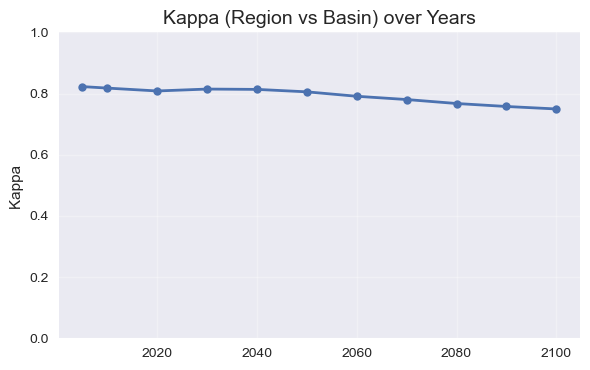

In [9]:
years = list(range(2010, 2101, 10))   # 2010,2020,...,2100
years.insert(0, 2005)
names = ["agri","forest","grassland"]
accuracy = "F"

kappa_list,accuracy_list = kappa_calc_mode(ds,years,names,accuracy)
kappa_plot_mode(years,kappa_list,accuracy_list,accuracy)

# kappa_list_r,kappa_list_b = kappa_calc_year(ds,years,names,accuracy) 
# kappa_plot_year_combined(years, kappa_list_r, kappa_list_b)